# SUA spatial distibution of different types of units in cortical space

## Import

In [1]:
import os 
os.chdir('/CSNG/studekat/ripple_paper_clean/code')

In [2]:
from functions_analysis import *
import pandas as pd
import numpy as np
import yaml
import pickle
import neo
import matplotlib.pyplot as plt

## Parameters

In [3]:
with open("/CSNG/studekat/ripple_paper_clean/code/params_analysis.yml") as f:
    params = yaml.safe_load(f)

DATA_FOLDER = params['data_folder']  # folder with all the preprocessed data
DATES = params['dates']

DF_FOLDER = '/CSNG/studekat/ripple_paper_clean/dataframes'  # original version of the dataframes loading 
MONKEY_LIST = ['L','N','F']
AREAS_MERGED = params['areas_merged']
FINAL_CLASSES = params['final_classes']
COLORS_CLASSES = params['colors_class']

In [4]:
L_coors =np.array([[1,1],[0,0],[0,1],[2,2],  # row, col, the first 4 arrays
           [1,2],[2,3],[1,3],[2,4],
           [1,7],[2,7],[3,7],[1,6],
           [2,6],[1,5],[2,5],[1,4]])

In [5]:
N_coors =np.array([[1,4],[2,3],[2,4],[1,5],  # row, col, the first 4 arrays
           [2,5],[1,6],[2,7],[1,7],
           [1,2],[1,3],[0,4],[0,3],
           [0,2],[1,1],[0,1],[0,0]])

In [6]:
F_coors = np.array([[1,9],[0,9],[1,8],[0,8],  # row, col, the first 4 arrays
           [1,7],[0,7],[1,6],[1,5],
           [0,0],[0,1],[1,1],[0,2],
           [1,2],[0,3],[0,4],[0,5]])

In [7]:
A_coors = np.array([[1,1],[0,0],[0,1],[2,2],  # row, col, the first 4 arrays
           [1,2],[2,3],[1,3],[2,4],
           [1,7],[2,7],[3,7],[1,6],
           [2,6],[1,5],[2,5],[1,4]])

In [8]:
arrays_coors = {'A':A_coors,
              'L':L_coors,
              'N':N_coors,
              'F':F_coors,}
n_rows_dict = {'A':4,
              'L':4,
              'N':3,
              'F':2,}
n_cols_dict = {'A':8,
              'L':8,
              'N':8,
              'F':10,}

## Plotting

Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.


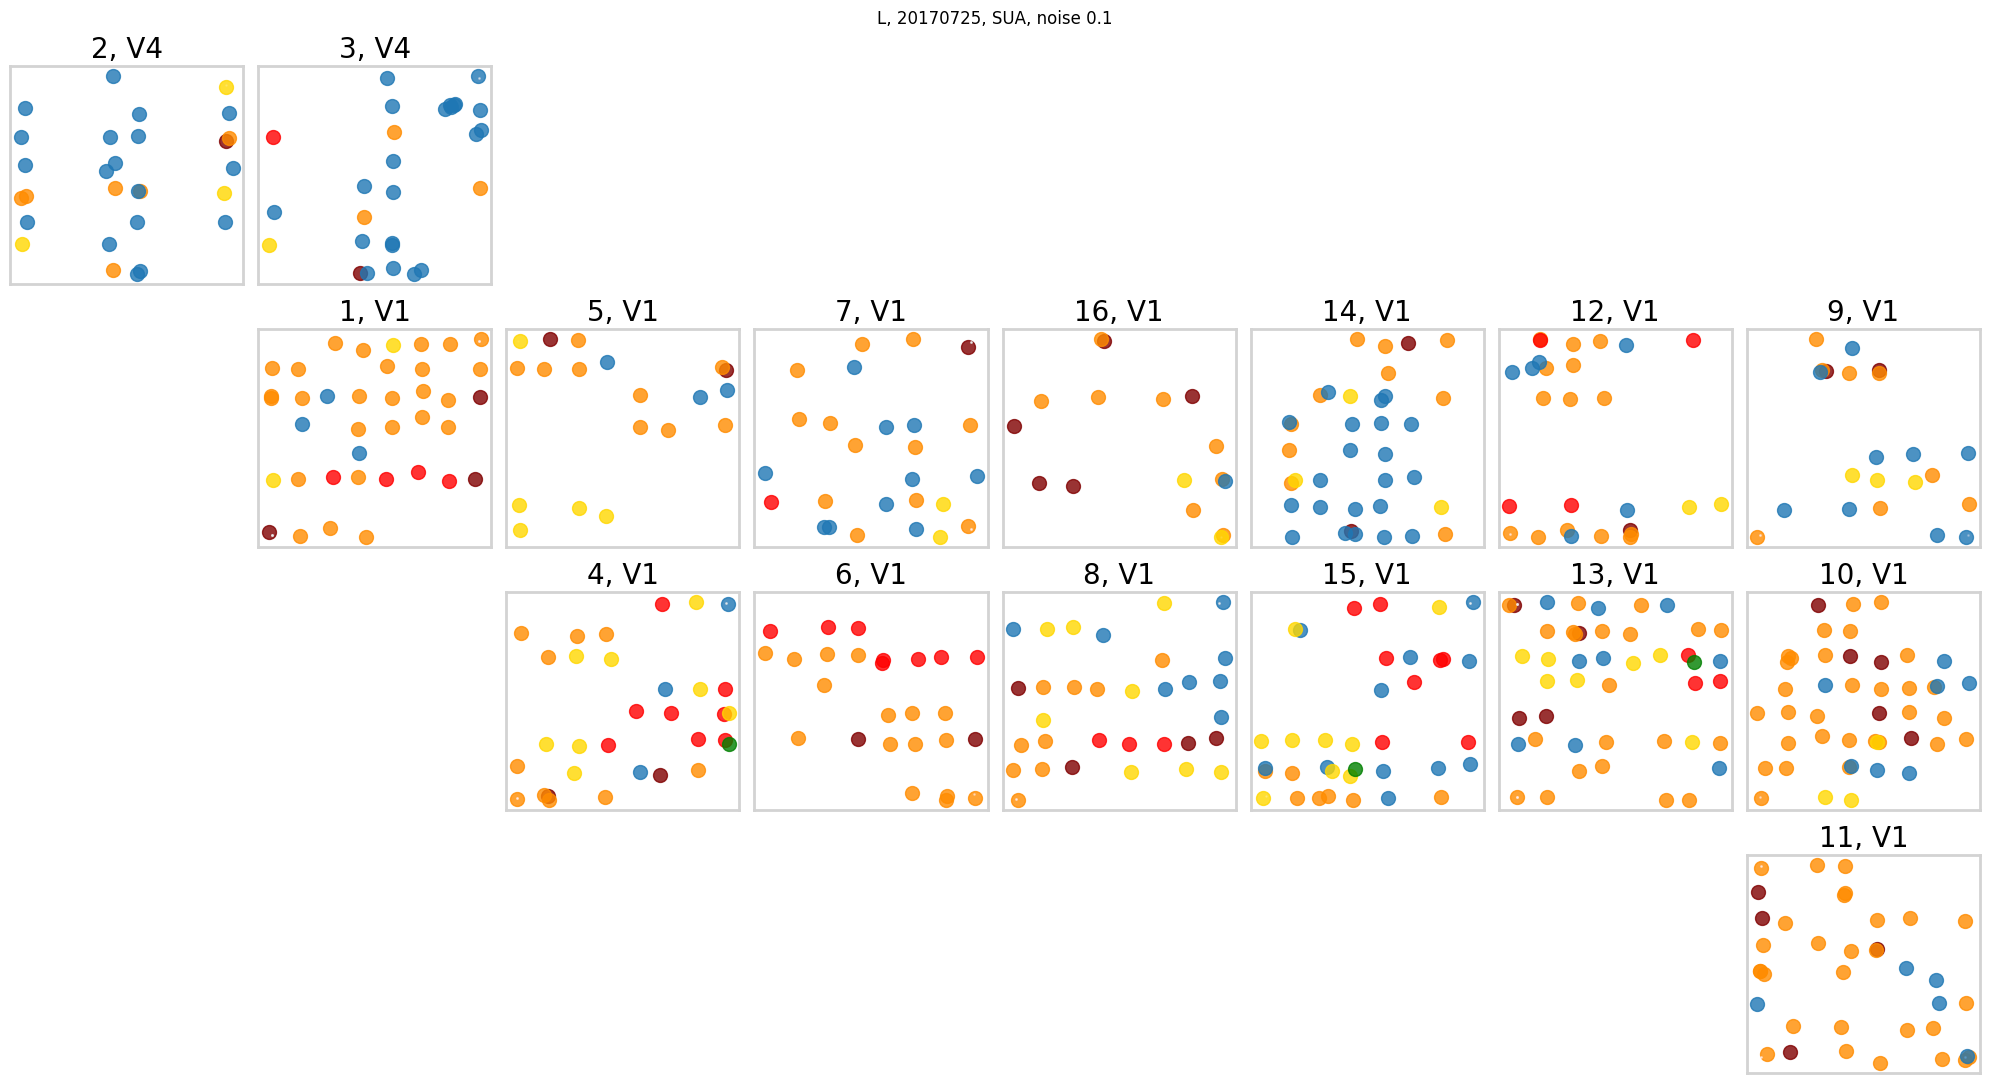

Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.


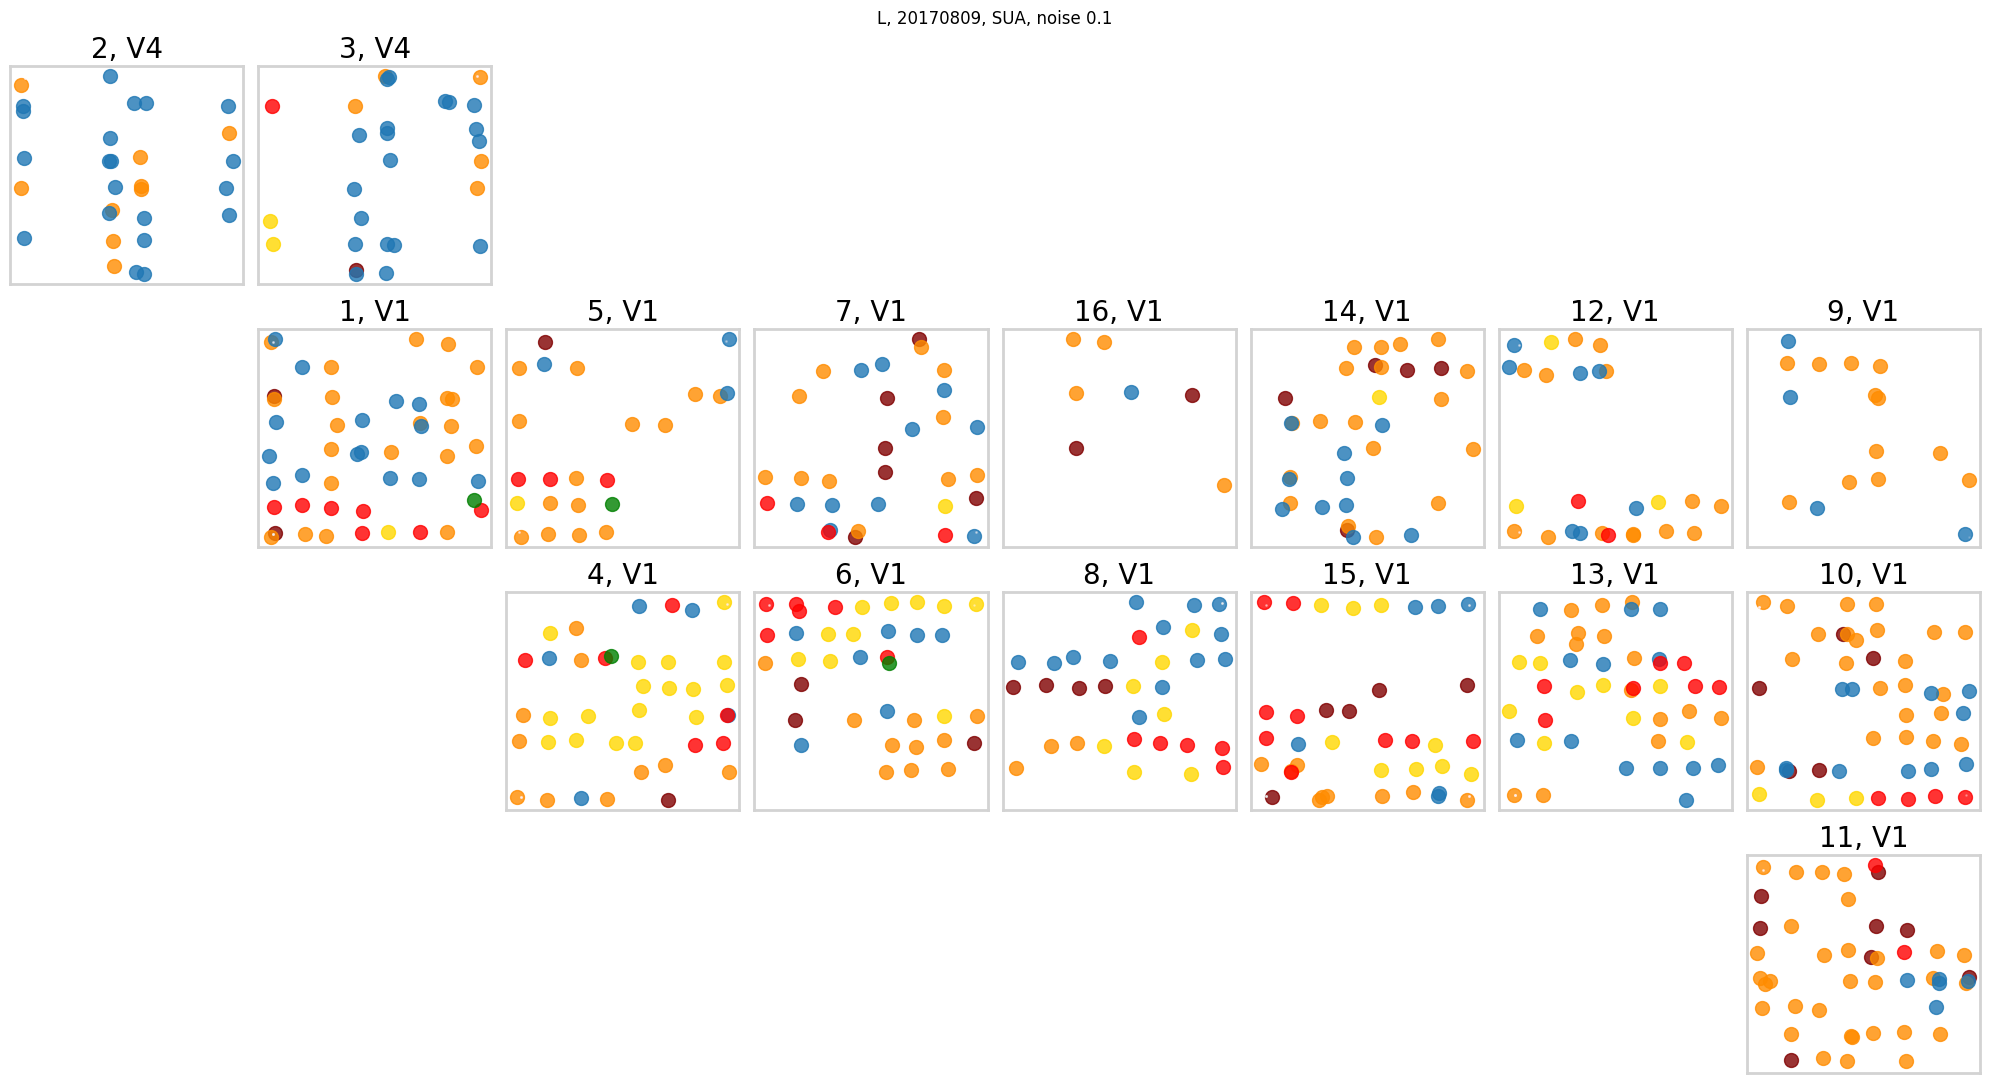

Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.


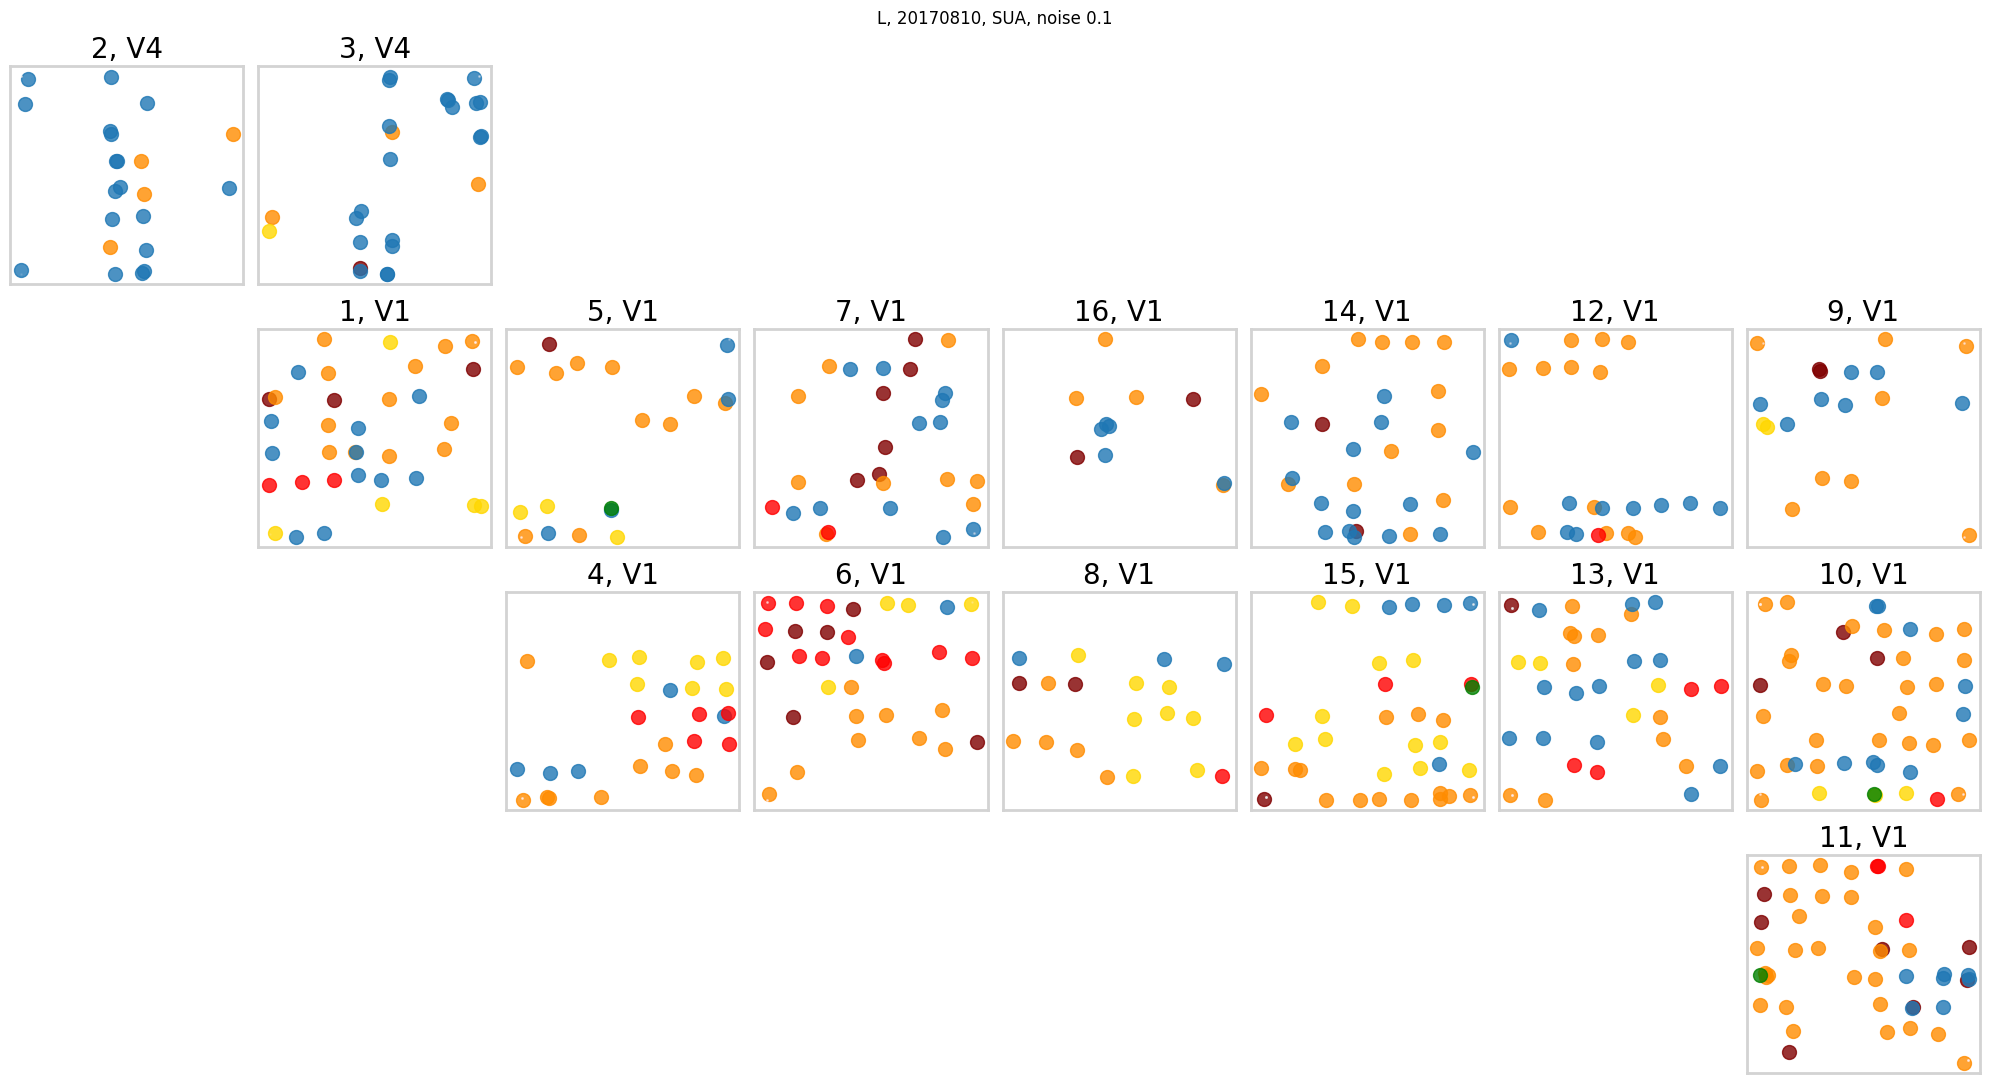

Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.


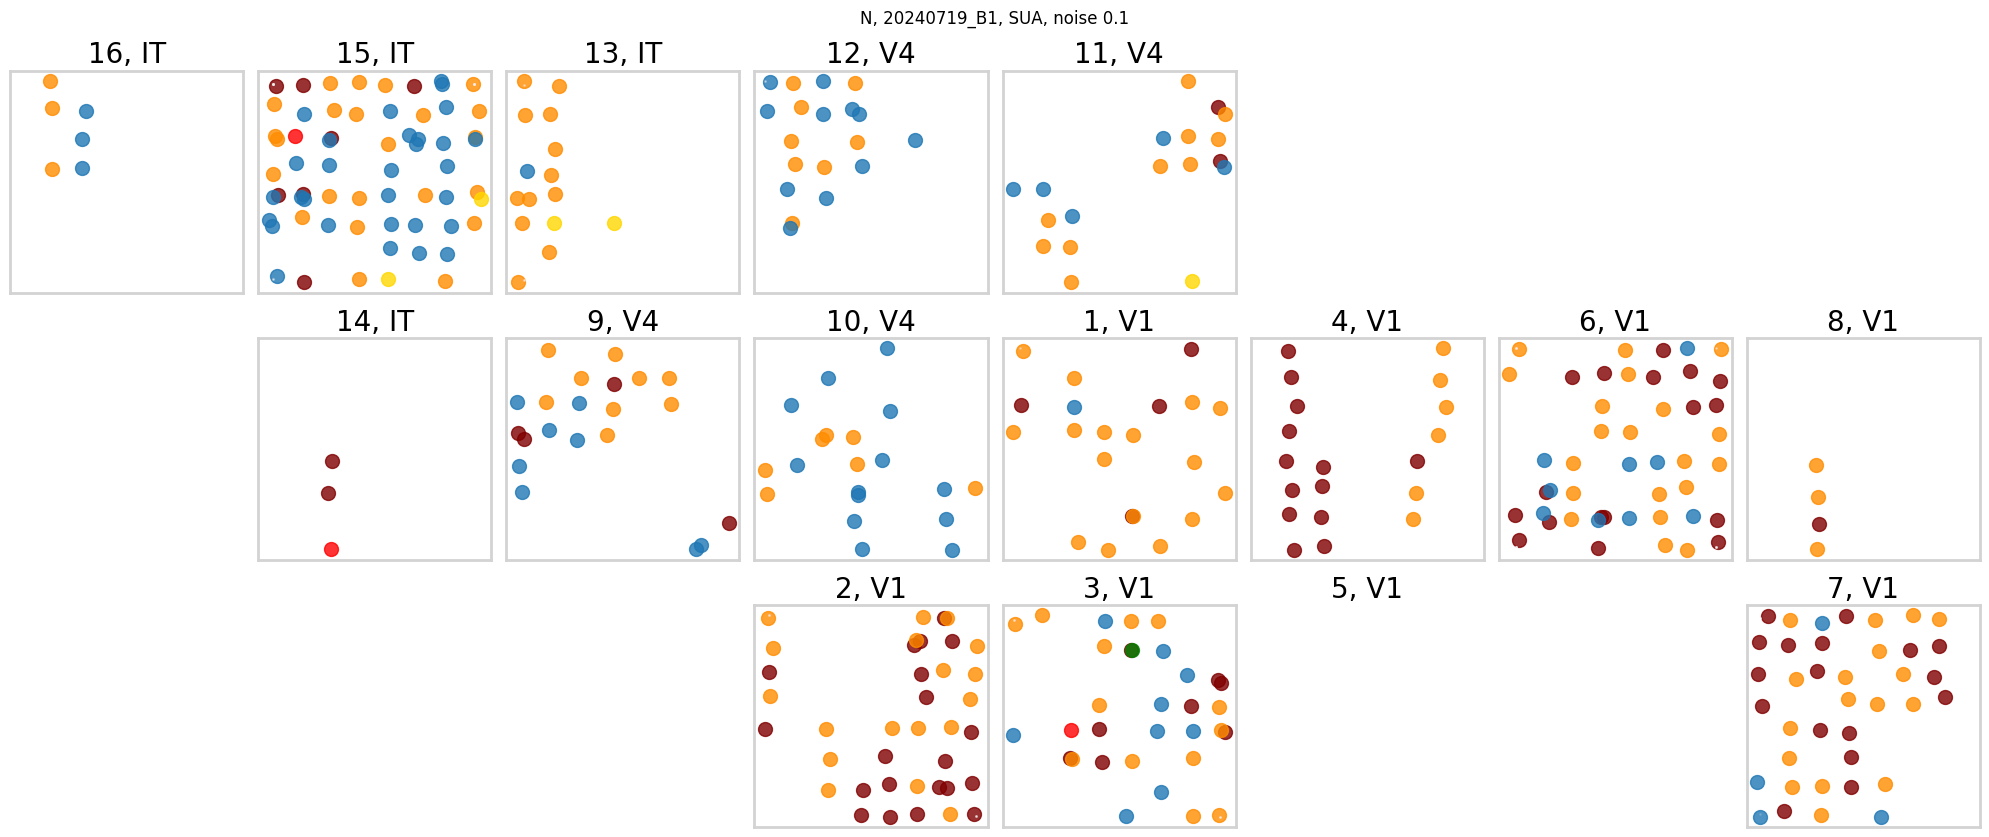

Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.


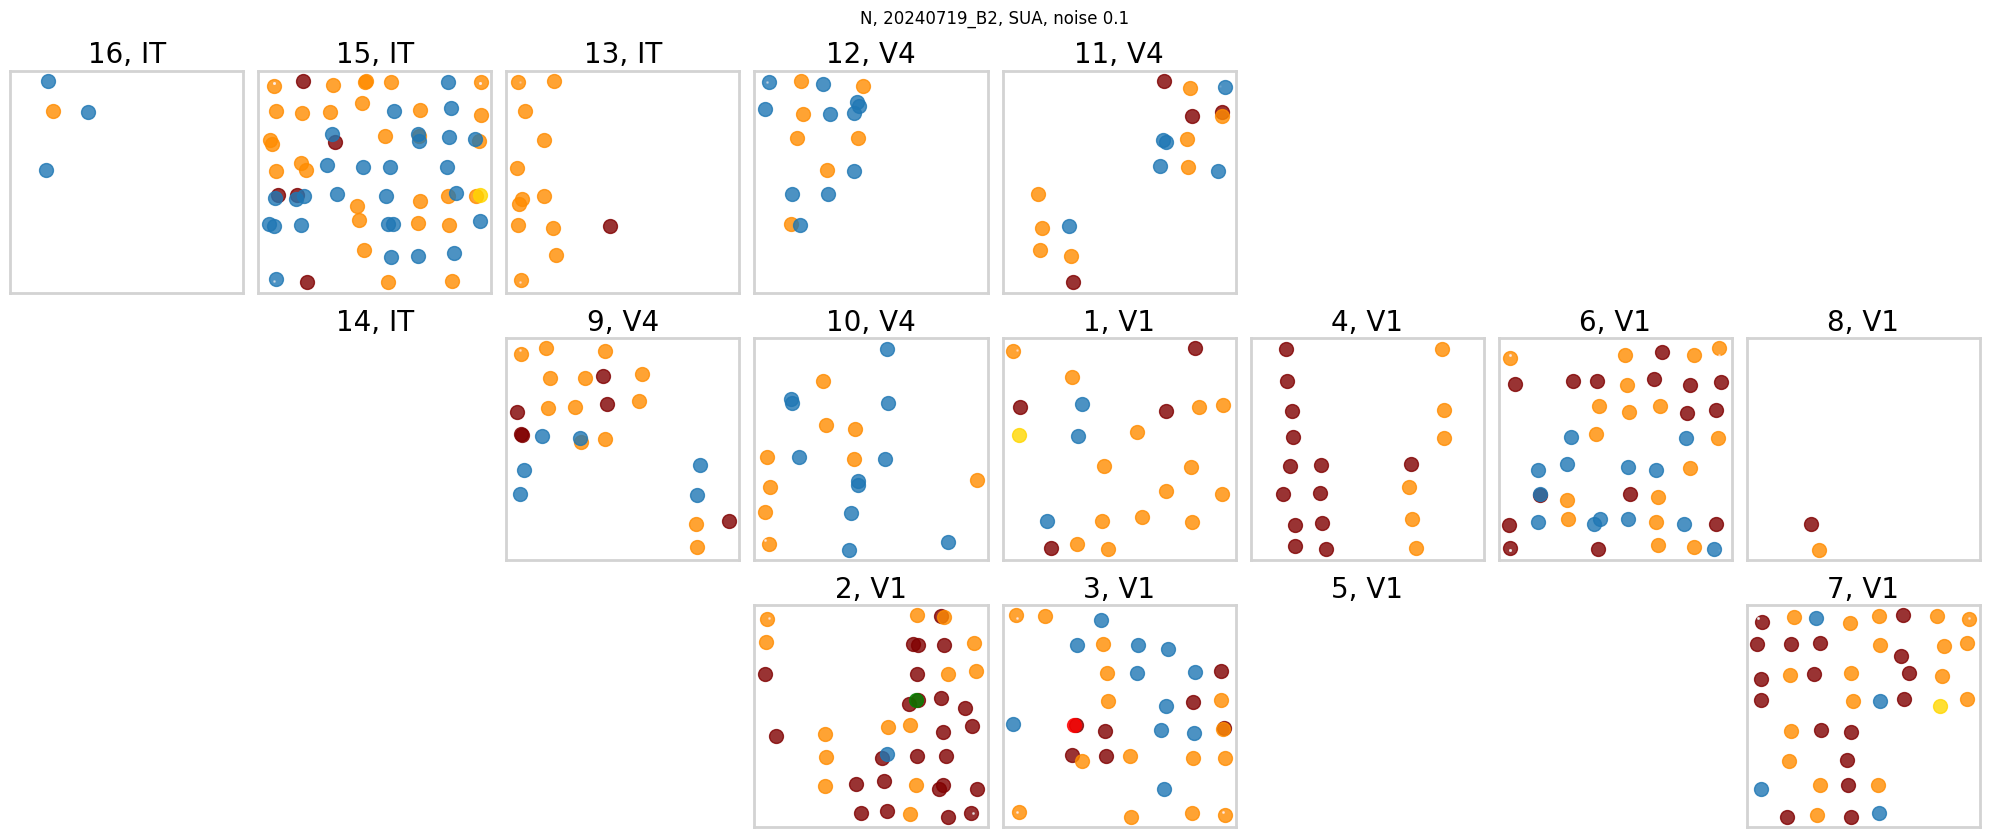

Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.


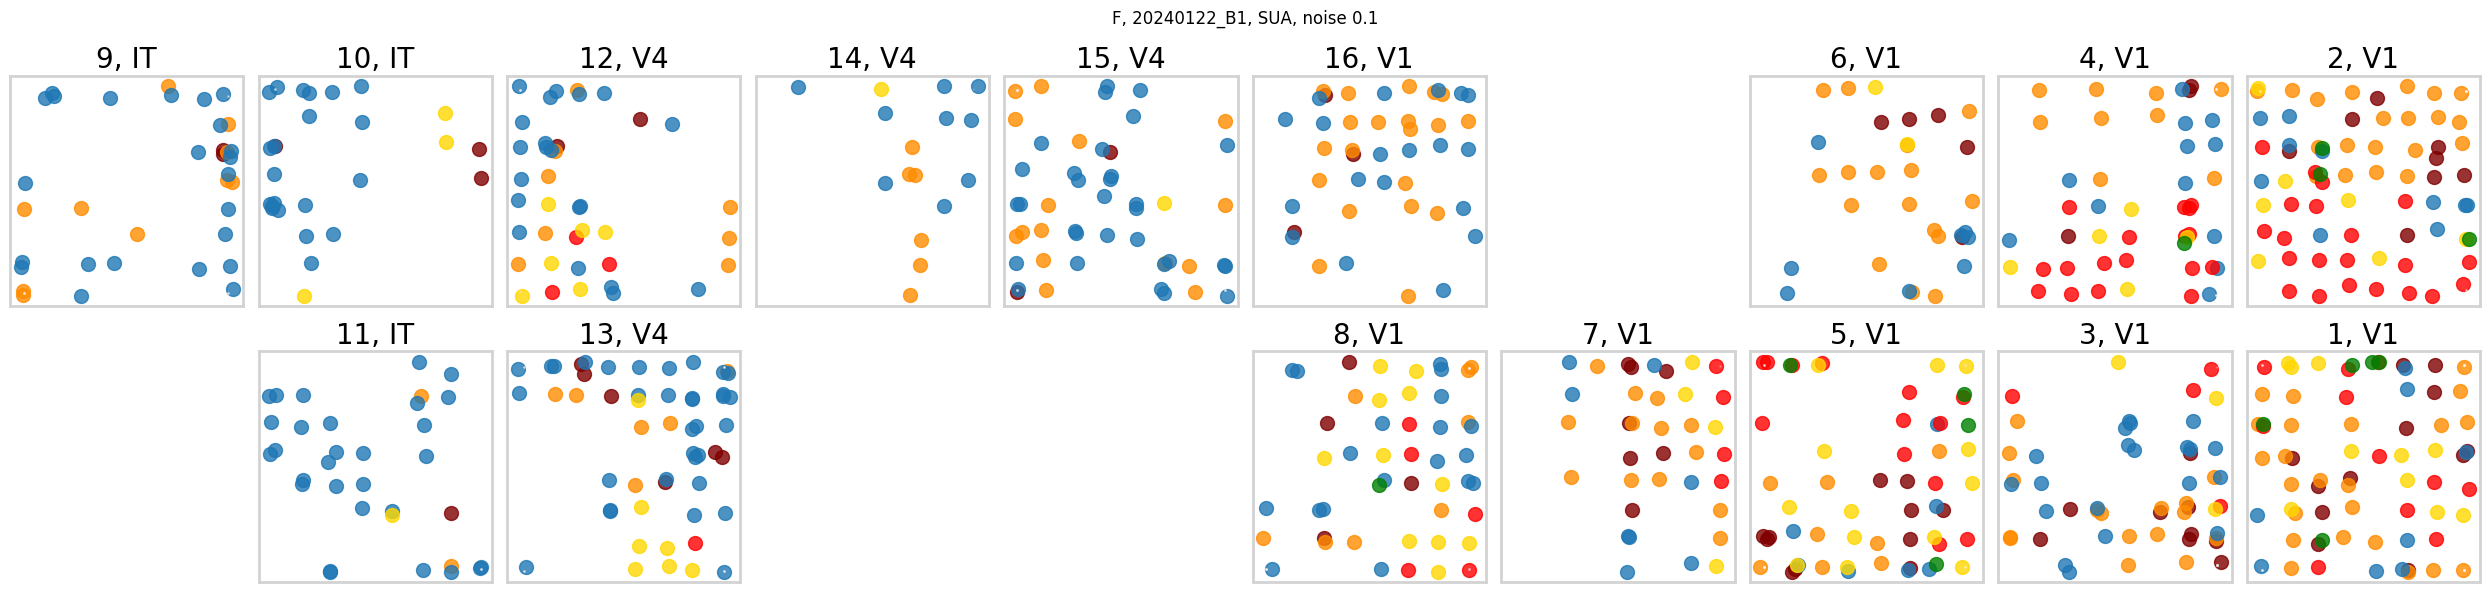

Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.
Odd.
Even.


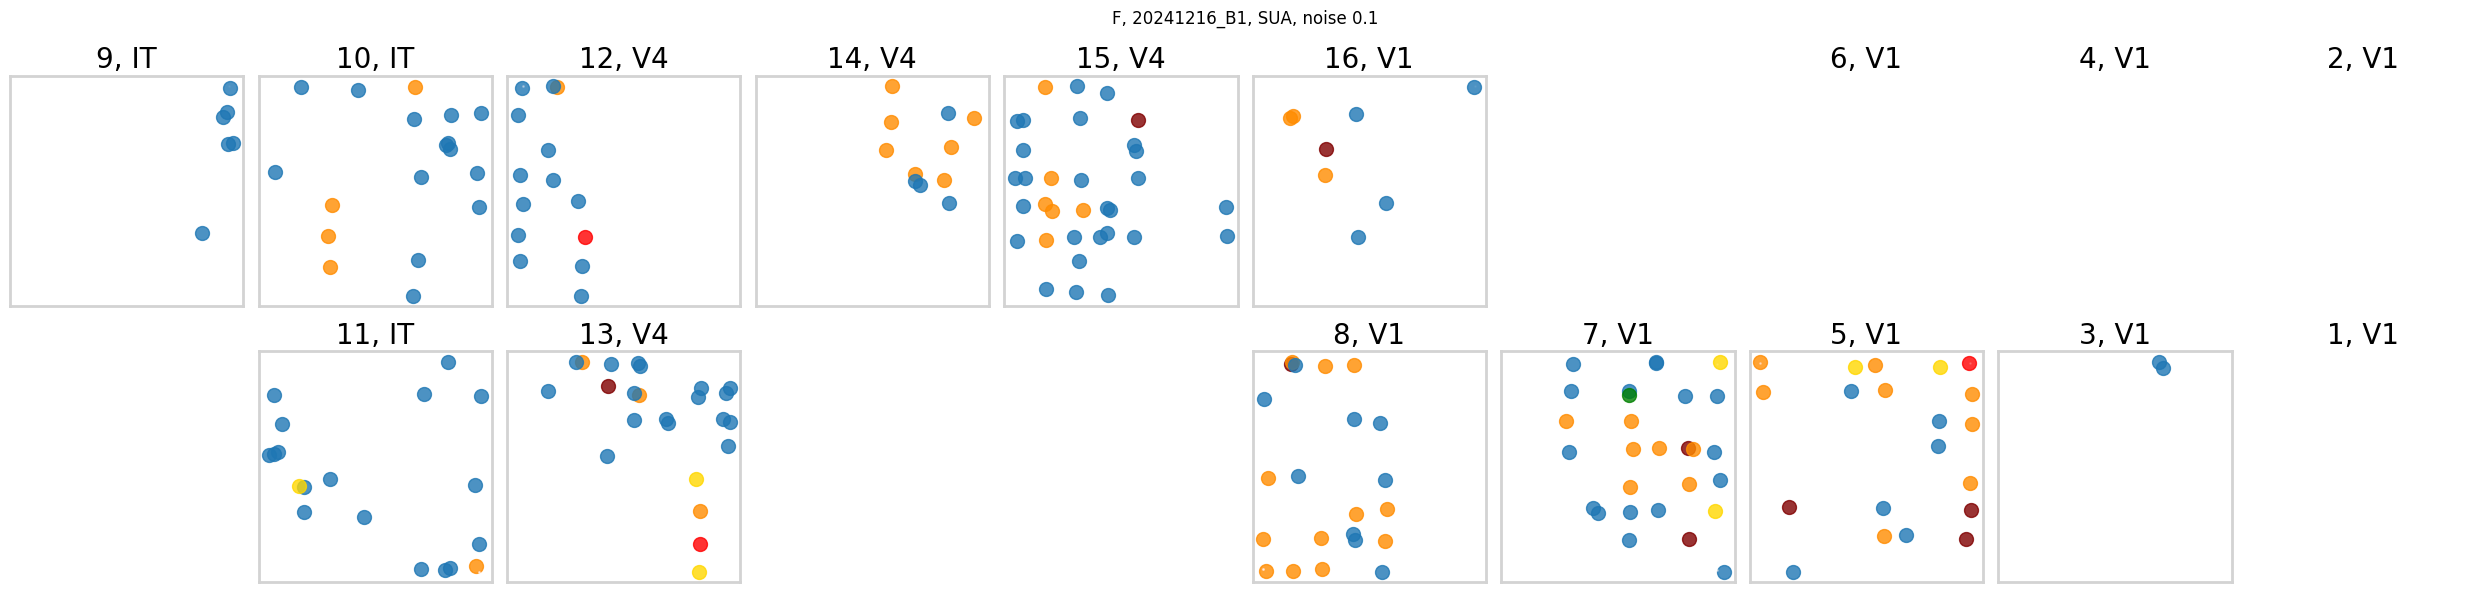

In [9]:
noise_level = 0.10

for monkey in MONKEY_LIST:
    layout_odd = np.array(params['layout'][f'{monkey}_odd'])
    layout_even = np.array(params['layout'][f'{monkey}_even'])
    for date in params['dates'][monkey]['RS']:
        with open(f'{DF_FOLDER}/sua_prop_all/monkey{monkey}_all_arrays_date_{date}.pkl', "rb") as file:
            df_prop = pickle.load(file)
        #print(df_prop.shape)
        df_prop = df_prop[~df_prop['ch_is_noisy_120Hz']]
        df_prop = df_prop[~df_prop['ch_is_noisy_100Hz']]
        #print(df_prop.shape)
        #print()

        arr_dict = {arr:{} for arr in range(1,17)}
        ch_dict = {arr:{} for arr in range(1,17)}
        for array in range(1,17):
            df_arr = df_prop[df_prop['array']==array]
            if array%2==0:
                layout = layout_even
                print('Even.')
            else:
                layout = layout_odd
                print('Odd.')
            for cl in FINAL_CLASSES:
                arr_dict[array][cl] = []
                ch_dict[array][cl] = []
            for cell_idx in df_arr.index:
                df_cell = df_arr.loc[cell_idx]
                cell_class = df_cell['final_class']
                cell_ch = df_cell['channel_order']
                layout_idx = np.where(layout==cell_ch)
                layout_idx = np.array([layout_idx[0][0], layout_idx[1][0]]) # reformating from array of arrays to array of two integer coors.
                arr_dict[array][cell_class].append(layout_idx)
                ch_dict[array][cell_class].append(cell_ch)

        n_rows = n_rows_dict[monkey]
        n_cols = n_cols_dict[monkey]
        fig, ax = plt.subplots(n_rows,n_cols)
        fig.set_figwidth(2.5*n_cols)
        fig.set_figheight(2.5*n_rows+1)
        
        plt.suptitle(f'{monkey}, {date}, SUA, noise {noise_level}')
        
        for r in range(n_rows):
            for c in range(n_cols):
                ax[r,c].set_xticks([])
                ax[r,c].set_yticks([])
                for spine in ax[r,c].spines.values():
                    spine.set_color('white')
        
        for array in range(1,17):
            area = params['areas'][monkey][array-1]
            arr_coors_all_cl = arr_dict[array]  # dict. with coordinates of all SUA
            row_plot = arrays_coors[monkey][array-1][0]
            col_plot = arrays_coors[monkey][array-1][1]
            ax[row_plot,col_plot].set_title(f'{array}, {area}',fontsize=20)
            for cl in FINAL_CLASSES:
                color = COLORS_CLASSES[cl]
                coors_cl = arr_coors_all_cl[cl]
                channels_cl = ch_dict[array][cl]
                for coor, ch in zip(coors_cl,channels_cl):
                    row = coor[1]
                    col = coor[0]
                    row_noisy = row + np.random.normal(0, noise_level)
                    col_noisy = col + np.random.normal(0, noise_level)
                    ax[row_plot,col_plot].scatter(row_noisy,7-col_noisy,c=color,alpha=0.8,s=100)
                    ax[row_plot,col_plot].scatter([0,7,0,7],[0,0,7,7],c='white',s=1,alpha=0.05)  # to make sure scatter plot is from 0 to 8 channels
                    #ax[row_plot,col_plot].scatter(row,8-col,c=color,alpha=0.8,s=100)  # to test the channel organisation in layout
                    """
                    # Add text labels on top of each dot
                    ax[row_plot, col_plot].text(
                        row, 8-col,
                        #f"{row},{col}",          # what to print
                        ch,
                        ha='center', va='center',
                        fontsize=8, color='black'
                    )
                    """
                    
                    for spine in ax[row_plot,col_plot].spines.values():
                        spine.set_color('lightgray')
                        spine.set_linewidth(2)
            
        plt.tight_layout()
        plt.show()
        plt.close()